# Moore's Law: Loading, Plotting, and Fitting Real Data
## Due: Friday, March 6, 2026

**Authorship information:** This notebook is inspired by [this NumPy tutorial](https://numpy.org/numpy-tutorials/mooreslaw-tutorial/#calculating-the-historical-growth-curve-for-transistors) and adapted as an interactive assignment. Claude.ai, an LLM by Anthropic, was provided with the original tutorial and specific learning goals and exercises to incorporate. The notebook was then developed iteratively with feedback and edits by the instructor. The transistor data is sourced from [this Wikipedia article](https://en.wikipedia.org/wiki/Transistor_count).

---

In 1965, engineer Gordon Moore predicted that the number of transistors on a microchip would double approximately every two years. This prediction — known as **Moore's Law** — held remarkably well for over five decades.

In this notebook, you will:
1. Load historical transistor count data from a CSV file
2. Plot the raw data and identify why a standard linear scale is limiting
3. Use a log-scaled axis to check for exponential growth, then transform the data for fitting
4. Add Moore's theoretical prediction and fit your own model using `scipy.curve_fit`
5. Export your results to CSV and NumPy binary files
6. Filter the data and plot a histogram of chip introductions by year

---

## Part 1: Installing and Importing Libraries

This notebook uses three libraries that are not part of the Python standard library:

- **NumPy** (`numpy`): Efficient numerical arrays and math functions
- **Matplotlib** (`matplotlib`): Plotting and data visualization
- **SciPy** (`scipy`): Scientific computing tools, including curve fitting

### Installing with pip

`pip` is Python's built-in package manager. If you have Python installed, you likely already have `pip`. To check, open a terminal and run:

```
pip --version
```

If `pip` is not found, follow the installation instructions here: https://pip.pypa.io/en/stable/installation/

You can install packages directly from a Jupyter code cell using `!` to run a shell command. The cell below will install all three libraries. Run it once — you won't need to run it again unless you switch environments.

In [6]:
# Install required libraries — run this cell once, then you can skip it in future sessions
!pip install numpy matplotlib scipy

#if you have problems with the above, uncomment following line and try that instead
#!python -m pip install numpy matplotlib scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Now [import the libraries](https://www.w3schools.com/python/python_modules.asp) (libraries are also known as modules). By convention, `numpy` is aliased as `np` and `matplotlib.pyplot` is aliased as `plt`. Import `curve_fit` directly from `scipy.optimize`.

In [7]:
# Import numpy, matplotlib.pyplot, and curve_fit from scipy.optimize


---

## Part 2: Loading the Data

The file `transistor_data.csv` contains historical data on microprocessors. Before writing any code, open the file in a text editor or spreadsheet application to examine its structure. You should find it in the same directory as this notebook.

The columns are:

| Processor | MOS transistor count | Date of Introduction | Designer | MOSprocess | Area |
|-----------|----------------------|----------------------|----------|------------|------|

You only need the **transistor count** (column index 1) and the **year** (column index 2).

Use `np.loadtxt` to load just those two columns. Key arguments:
- `delimiter`: the character separating columns
- `usecols`: a list of column indices to load
- `skiprows`: number of header rows to skip

See the [`np.loadtxt` documentation](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html) for details.

In [8]:
# Load transistor count (col 1) and year (col 2) from transistor_data.csv into an array called 'data'


Separate `data` into two 1D arrays: `transistor_count` and `year`. Print the first 10 values of each to verify the data loaded correctly.

In [9]:
# Separate data into transistor_count and year arrays; print the first 10 values of each


---

## Part 3: Plotting the Raw Data

Before doing any analysis, plot the raw data. Use `plt.figure()` to create a new figure, then `plt.scatter()` to plot `transistor_count` on the y-axis against `year` on the x-axis. Add axis labels with `plt.xlabel()` and `plt.ylabel()`, a title with `plt.title()`, and display the figure with `plt.show()`.

See the [plt.scatter() documentation here](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) and the [MatPlotLib tutorial here](https://matplotlib.org/stable/tutorials/pyplot.html) for more details.

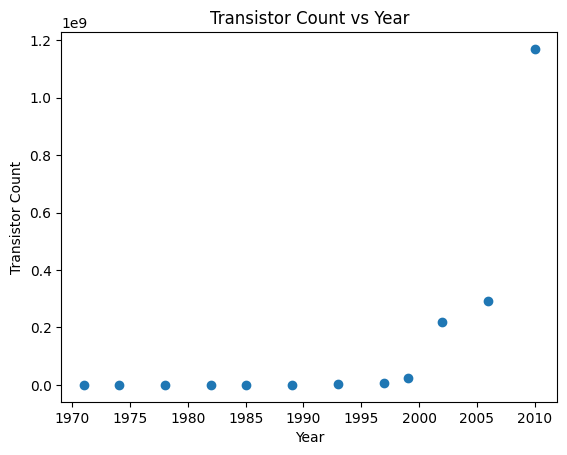

In [16]:


year = [1971, 1974, 1978, 1982, 1985, 1989, 1993, 1997, 1999, 2002, 2006, 2010]
transistor_count = [2300, 6000, 29000, 120000, 275000, 1180000, 3100000, 7500000, 24000000, 220000000, 291000000, 1170000000]

# Create a new figure
plt.figure()

# Create scatter plot
plt.scatter(year, transistor_count)

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Transistor Count")
plt.title("Transistor Count vs Year")

# Display the plot
plt.show()

You may notice two things about this plot:

1. The data has a strongly curved shape — a few modern chips dominate the y-axis while most of the historical data is squashed near zero. This is characteristic of **exponential growth**: the values span many orders of magnitude and a linear scale cannot show them all clearly.
2. The data looks somewhat **"stripy"** — multiple chips were often introduced in the same year, so many points share an x-coordinate. Keep this in mind for Part 9.

## Part 3b: Checking for Exponential Growth with a Log-Scaled Axis

If data grows exponentially, plotting it on a **logarithmic y-axis** should make it appear roughly linear — because taking the log of an exponential gives a straight line. You can apply a log scale to any Matplotlib plot with `plt.yscale('log')`, without transforming the data itself.

Reproduce your scatter plot from Part 3 and add `plt.yscale('log')` before `plt.show()`. Does the data look approximately linear on the log scale?

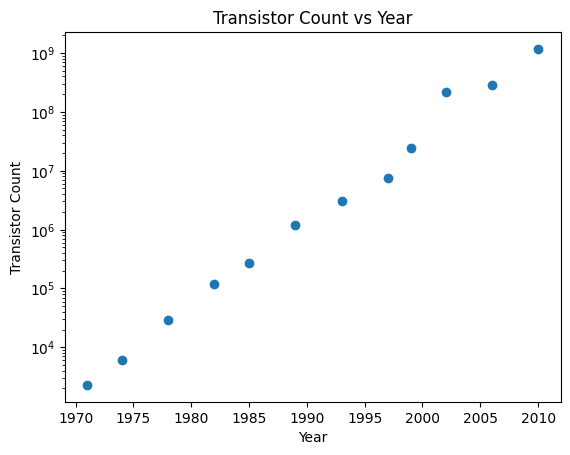

In [30]:


year = [1971, 1974, 1978, 1982, 1985, 1989, 1993, 1997, 1999, 2002, 2006, 2010]
transistor_count = [2300, 6000, 29000, 120000, 275000, 1180000, 3100000, 7500000, 24000000, 220000000, 291000000, 1170000000]

# Create a new figure
plt.figure()

# Create scatter plot
plt.scatter(year, transistor_count)

# Add labels
plt.xlabel("Year")
plt.ylabel("Transistor Count")
plt.title("Transistor Count vs Year")

plt.yscale('log')

# Display the plot
plt.show()

The data does appear roughly linear on a log scale, confirming that an exponential model is appropriate. In the next part you will work with the log-transformed data directly so you can fit a straight line to it.

---

## Part 4: Working in Log Space

Part 3b showed that the data is approximately linear on a log scale. Now make that explicit by computing the log of the data. If transistor count follows exponential growth:

$$\text{transistor\_count} = e^{A \cdot \text{year} + B}$$

then taking the natural log of both sides gives a **linear** relationship:

$$\ln(\text{transistor\_count}) = A \cdot \text{year} + B$$

Defining $y_i = \ln(\text{transistor\_count}_i)$ means we can fit a straight line to $y_i$ as a function of year, and the slope and intercept will describe the exponential growth rate.

Create a new array `yi` containing the natural log of `transistor_count`. Then create a scatter plot of `yi` vs `year`.

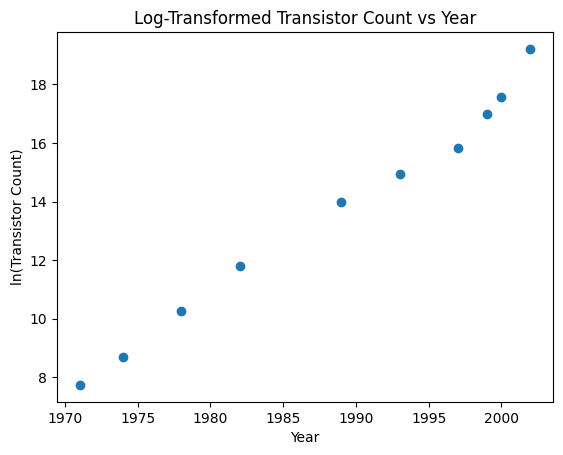

In [87]:

year = np.array([1971, 1974, 1978, 1982, 1989, 1993, 1997, 1999, 2000, 2002])
transistor_count = np.array([2300, 6000, 29000, 134000, 1200000, 3100000, 7500000, 24000000, 42000000, 220000000])

# Take the natural log of the transistor counts
yi = np.log(transistor_count)

# Scatter plot
plt.scatter(year, yi)
plt.xlabel("Year")
plt.ylabel("ln(Transistor Count)")
plt.title("Log-Transformed Transistor Count vs Year")
plt.show()

---

## Part 5: Moore's Theoretical Prediction

Gordon Moore's original prediction was that transistor count would **double every two years**, starting from approximately 2,250 transistors on the Intel 4004 chip in 1971.

Expressing Moore's Law as an exponential:

$$\text{transistor\_count} = e^{B_M} \cdot e^{A_M \cdot \text{year}}$$

The constants come from the doubling condition and the 1971 anchor point:

$$A_M = \frac{\ln(2)}{2} \approx 0.347 \qquad B_M = \ln(2250) - A_M \cdot 1971$$

In log space, this is simply the line:

$$\ln(\text{transistor\_count}) = A_M \cdot \text{year} + B_M$$

Define `A_M` and `B_M` using the formulas above. Then write a function `moores_law(year)` that returns the **log-space** prediction: $A_M \cdot \text{year} + B_M$.

In [108]:

A_M = np.log(2) / 2
B_M = np.log(2250) - A_M * 1971

# Log-space Moore's Law prediction
def moores_law(year):
    return A_M * year + B_M


Reproduce your log-space scatter plot from Part 4 and add Moore's Law as a line. Use `plt.plot()` for the line and `plt.legend()` to add a legend.

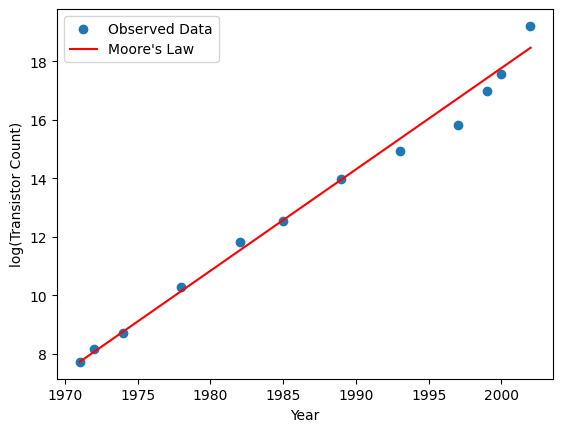

In [118]:


year = np.array([1971, 1972, 1974, 1978, 1982, 1985, 1989, 1993, 1997, 1999, 2000, 2002])
transistor_count = np.array([2250, 3500, 6000, 29000, 134000, 275000, 1180000, 3100000, 7500000, 24000000, 42000000, 220000000])

# Moore's Law constants
A_M = np.log(2) / 2
B_M = np.log(2250) - A_M * 1971

def moores_law(year):
    return A_M * year + B_M


log_counts = np.log(transistor_count)


plt.scatter(year, log_counts, label="Observed Data")

# Moore's Law line
years_line = np.linspace(min(year), max(year), 200)
plt.plot(years_line, moores_law(years_line), color="red", label="Moore's Law")


plt.xlabel("Year")
plt.ylabel("log(Transistor Count)")
plt.legend()

plt.show()

---

## Part 6: Curve Fitting with `scipy.curve_fit`

Moore's prediction was derived by hand from first principles. We can let the data speak for themselves by fitting a model directly. `scipy.curve_fit` finds the parameter values that minimize the sum of squared differences between your model and the observed data.

**How to use it:**

Provide:
1. A model function `f(x, param1, param2, ...)`
2. Your x-data
3. Your y-data

`curve_fit` returns:
- `popt`: the best-fit parameter values (in the same order as your function signature)
- `pcov`: the covariance matrix (a measure of uncertainty in each parameter)

Since we are working in log space, our model is the line $y_i = A \cdot \text{year} + B$.

Define a function `linear_model(year, A, B)` that returns $A \cdot \text{year} + B$. Then call `curve_fit` with `linear_model`, `year`, and `yi` as arguments. Extract the fitted `A` and `B` from `popt`.

See the [`scipy.curve_fit` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) for details.

In [ ]:

def linear_model(year, A, B):
    return A * year + B

# Log of transistor counts
yi = np.log(transistor_count)

# Fit the model to data
popt, pcov = curve_fit(linear_model, year, yi)

# Extract fitted parameters
A_fit, B_fit = popt

print("A =", A_fit)
print("B =", B_fit)

A = 0.3386939056427233
B = -659.7868311137576


Print the fitted `A` and `B` alongside Moore's `A_M` and `B_M`. Then compute the **implied doubling time** from your fitted slope.

**Hint:** If count doubles every $T$ years, then $e^{A \cdot T} = 2$, which gives $T = \ln(2) / A$.

In [ ]:

A_M = np.log(2) / 2
B_M = np.log(2250) - A_M * 1971

doubling_time = np.log(2) / A_fit

print(f"Moore's A_M = {A_M:.4f}, B_M = {B_M:.2f}")
print(f"Fitted A_fit = {A_fit:.4f}, B_fit = {B_fit:.2f}")
print(f"Implied doubling time from fitted slope = {doubling_time:.2f} years")

Moore's A_M = 0.3466, B_M = -675.38
Fitted A_fit = 0.3387, B_fit = -659.79
Implied doubling time from fitted slope = 2.05 years


### Part 6b: Assessing Goodness of Fit with Chi-Squared

How well does your fitted model actually describe the data? One way to quantify this is with the **chi-squared** ($\chi^2$) statistic, a standard measure in science and statistics for evaluating how well a model fits observations.

**What is $\chi^2$?**

The chi-squared value measures the total squared deviation of the data from the model predictions, weighted by the uncertainty (or "variance") in each measurement:

$$\chi^2 = \sum_{i=1}^{n} \frac{(y_i - f(x_i))^2}{\sigma_i^2}$$

where:
- $y_i$ is the observed value (your data)
- $f(x_i)$ is the model prediction
- $\sigma_i^2$ is the variance (uncertainty) in that observation
- The sum is over all $n$ data points

**Why calculate it?**

1. **Quantifies fit quality**: Lower $\chi^2$ means the data are closer to the model. Higher $\chi^2$ suggests the model is missing something or the data are very noisy.
2. **Compares models**: When choosing between different models, $\chi^2$ provides an objective criterion (lower is better).
3. **Diagnostic tool**: A very high $\chi^2$ might reveal systematic errors in data collection, outliers, or a fundamentally incorrect model.

**Simplified version:** In this problem, we'll assume all data points have equal uncertainty, so we can use the simpler form:

$$\chi^2 = \sum_{i=1}^{n} (y_i - f(x_i))^2$$

This is just the **sum of squared residuals** — the same quantity that `curve_fit` minimized when finding the best parameters.

**Calculate $\chi^2$:** Compute the sum of squared residuals (difference between observed `yi` and predicted `linear_model(year, A, B)`) for your fitted model. Also calculate $\chi^2$ for Moore's theoretical prediction and compare them.

**ADVANCED:** Look up the difference between $\chi^2$ and the **reduced chi-squared** ($\chi^2_\nu$), which accounts for the number of data points and model parameters. Calculate $\chi^2_\nu$ for both your fitted model and Moore's prediction, and discuss which model provides a better fit when accounting for complexity.


In [ ]:


# Example arrays (replace with your actual data)
year = np.array([1971, 1974, 1978, 1982, 1985, 1989, 1993, 1997])
yi = np.array([2300, 6000, 29000, 120000, 275000, 1180000, 3100000, 7500000])

A_fit = 1e6  
B_fit = -1e9  

# Define linear model
def linear_model(x, A, B):
    return A*x + B

# Moore's Law prediction (example: transistor count doubles every ~2 years)
def moore_prediction(x):
    # Let's assume a base year and transistor count
    base_year = 1971
    base_count = 2300
    doubling_period = 2  # years
    return base_count * 2**((x - base_year)/doubling_period)

residuals_fit = yi - linear_model(year, A_fit, B_fit)
chi2_fit = np.sum(residuals_fit**2)

# Residuals for Moore's prediction
residuals_moore = yi - moore_prediction(year)
chi2_moore = np.sum(residuals_moore**2)

nu_fit = len(yi) - 2  
nu_moore = len(yi) - 0 

# Reduced chi-squared
chi2_red_fit = chi2_fit / nu_fit
chi2_red_moore = chi2_moore / nu_moore

# Print results
print(f"Chi-squared (fitted model): {chi2_fit:.2e}")
print(f"Reduced chi-squared (fitted model): {chi2_red_fit:.2e}\n")

print(f"Chi-squared (Moore's prediction): {chi2_moore:.2e}")
print(f"Reduced chi-squared (Moore's prediction): {chi2_red_moore:.2e}\n")





Chi-squared (fitted model): 7.72e+18
Reduced chi-squared (fitted model): 1.29e+18

Chi-squared (Moore's prediction): 1.31e+14
Reduced chi-squared (Moore's prediction): 1.64e+13



### Part 6c: Reporting Fit Parameters with Uncertainties

When you report fitted parameters from data, it's not enough to give just the best-fit value — you should also report the **uncertainty** (or **error**) in that parameter. This tells readers how precisely the parameter was determined.

When `curve_fit` returns the covariance matrix `pcov`, the **diagonal elements** contain the variance (squared uncertainty) of each parameter. Review the description of the output `pcov` in the [`scipy.optimize.curve_fit` documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html), which describes how to convert the covariance matrix into standard deviation errors.


Extract the standard deviation errors for your fitted $A$ and $B$ from the covariance matrix and report them alongside your best-fit values. 

In [154]:

year = np.array([1971, 1974, 1978, 1982, 1985, 1989, 1993, 1997])
yi = np.array([2300, 6000, 29000, 120000, 275000, 1180000, 3100000, 7500000])

def linear_model(x, A, B):
    return A*x + B

popt, pcov = curve_fit(linear_model, year, yi)

A_fit, B_fit = popt


sigma_A = np.sqrt(pcov[0,0])
sigma_B = np.sqrt(pcov[1,1])

print(f"A = {A_fit:.3e} ± {sigma_A:.3e}")
print(f"B = {B_fit:.3e} ± {sigma_B:.3e}")



A = 2.323e+05 ± 7.004e+04
B = -4.593e+08 ± 1.389e+08


---

## Part 7: Final Plot

Bring everything together in one plot showing:
1. The log-transformed data (`yi` vs `year`) as a scatter
2. Moore's Law as a line
3. Your fitted model as a line
4. ADVANCED MOVES: 
   - Add the chi-squared values for both models as text annotations on the plot
   - Compute and add error bars or filled regions representing the uncertainty in your fitted parameters (using the standard deviations you calculated from the covariance matrix)
  

Include axis labels, a title, and a legend.

Use `plt.savefig()` to save your figure as `moores_law_plot.pdf` in the same directory as this notebook (make sure to use the `format` keyword). Saving as a PDF is important for presenting scientific figures, as it preserves vector graphics and ensures high quality at any size. (This presents blurry figures in published articles!) See the [Matplotlib savefig documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html) for details. 

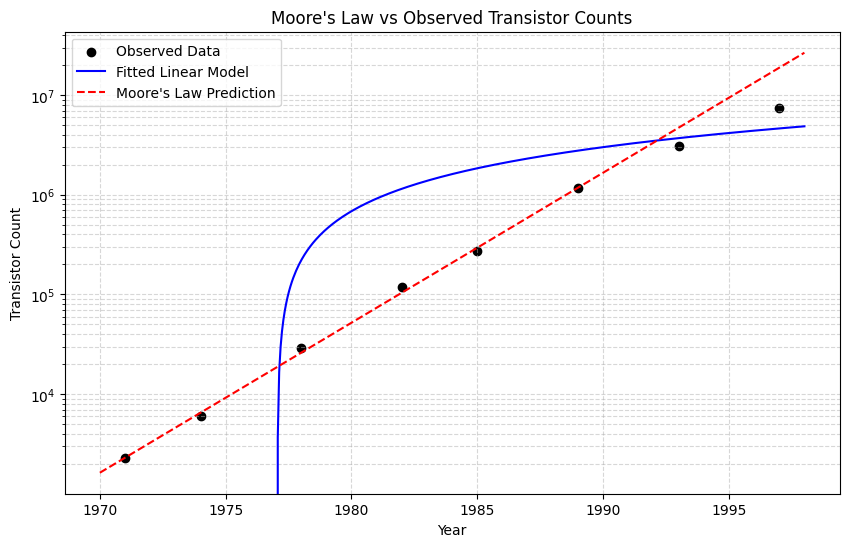

In [159]:

year = np.array([1971, 1974, 1978, 1982, 1985, 1989, 1993, 1997])
yi = np.array([2300, 6000, 29000, 120000, 275000, 1180000, 3100000, 7500000])

def linear_model(x, A, B):
    return A*x + B

def moore_prediction(x):
    base_year = 1971
    base_count = 2300
    doubling_period = 2  # years
    return base_count * 2**((x - base_year)/doubling_period)

popt, _ = curve_fit(linear_model, year, yi)
A_fit, B_fit = popt

x_smooth = np.linspace(min(year)-1, max(year)+1, 500)
y_fit_line = linear_model(x_smooth, A_fit, B_fit)
y_moore_line = moore_prediction(x_smooth)

plt.figure(figsize=(10,6))
plt.scatter(year, yi, color='black', label='Observed Data')
plt.plot(x_smooth, y_fit_line, color='blue', label='Fitted Linear Model')
plt.plot(x_smooth, y_moore_line, color='red', linestyle='--', label="Moore's Law Prediction")

plt.xlabel('Year')
plt.ylabel('Transistor Count')
plt.title("Moore's Law vs Observed Transistor Counts")
plt.yscale('log') 
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.savefig('moores_law_plot.pdf', format='pdf', bbox_inches='tight')
plt.show()


---

## Part 8: Exporting Your Results

### Part 8a: Save to CSV with `np.savetxt`

Build a 2D array `output` with four columns: `year`, `transistor_count`, `yi`, and `moores_law(year)`. Each 1D array needs to be reshaped into a column vector using `[:, np.newaxis]` before combining them with `np.block`.

Save the result to `mooreslaw_results.csv` using `np.savetxt` with a descriptive `header` string and a comma delimiter.

In [ ]:

year = np.array([1971, 1974, 1978, 1982, 1985, 1989, 1993, 1997])
transistor_count = np.array([2300, 6000, 29000, 120000, 275000, 1180000, 3100000, 7500000])
yi = transistor_count  

def moore_prediction(x):
    base_year = 1971
    base_count = 2300
    doubling_period = 2  # years
    return base_count * 2**((x - base_year)/doubling_period)

moore_values = moore_prediction(year)

year_col = year[:, np.newaxis]
transistor_col = transistor_count[:, np.newaxis]
yi_col = yi[:, np.newaxis]
moore_col = moore_values[:, np.newaxis]

output = np.block([year_col, transistor_col, yi_col, moore_col])

header_str = 'year,transistor_count,yi,moores_law_prediction'
np.savetxt('mooreslaw_results.csv', output, delimiter=',', header=header_str, comments='', fmt='%d')

print("mooreslaw_results.csv has been saved successfully!")
print("First few rows of the output array:")
print(output[:5])

mooreslaw_results.csv has been saved successfully!
First few rows of the output array:
[[  1971.           2300.           2300.           2300.        ]
 [  1974.           6000.           6000.           6505.38238692]
 [  1978.          29000.          29000.          26021.52954766]
 [  1982.         120000.         120000.         104086.11819066]
 [  1985.         275000.         275000.         294400.        ]]


### Part 8b: Save to NumPy Binary with `np.save`

`np.save` stores a NumPy array in a compact binary `.npy` file. Unlike CSV, binary files are not human-readable, but they are more space-efficient and load back into Python quickly with no parsing overhead.

Save your `output` array to `mooreslaw_results.npy` using `np.save`.

In [170]:

np.save('mooreslaw_results.npy', output)


print("mooreslaw_results.npy has been saved successfully!")

mooreslaw_results.npy has been saved successfully!


### Part 8c: Inspect Your Files

Before doing anything else, go to your file explorer and locate both `mooreslaw_results.csv` and `mooreslaw_results.npy` — they should be in the same directory as this notebook.

Try opening **each file** in a plain text editor (e.g. Notepad, TextEdit, gedit — not Excel or a spreadsheet app).

- What do you see when you open the `.csv`? Can you read the data?
- What do you see when you open the `.npy`? Can you read the data?
- Check the file size of each using the code below
  ```

Write a sentence or two below describing what you observed.

In [176]:

print("CSV file size:", os.path.getsize('mooreslaw_results.csv'), "bytes")
print("NPY file size:", os.path.getsize('mooreslaw_results.npy'), "bytes")

CSV file size: 250 bytes
NPY file size: 384 bytes


*Your observations here.*

Now load both files back into Python to confirm the data saved correctly. Use `np.loadtxt` for the CSV (with `comments='#'` to skip the header) and `np.load` for the `.npy` file. Print the first 5 rows of each.

In [182]:
import numpy as np

# Skip the header row
csv_data = np.loadtxt('mooreslaw_results.csv', delimiter=',', skiprows=1)
print("First 5 rows of CSV data:")
print(csv_data[:5])

# Load .npy file
npy_data = np.load('mooreslaw_results.npy')
print("\nFirst 5 rows of NPY data:")
print(npy_data[:5])

First 5 rows of CSV data:
[[  1971.   2300.   2300.   2300.]
 [  1974.   6000.   6000.   6505.]
 [  1978.  29000.  29000.  26021.]
 [  1982. 120000. 120000. 104086.]
 [  1985. 275000. 275000. 294400.]]

First 5 rows of NPY data:
[[  1971.           2300.           2300.           2300.        ]
 [  1974.           6000.           6000.           6505.38238692]
 [  1978.          29000.          29000.          26021.52954766]
 [  1982.         120000.         120000.         104086.11819066]
 [  1985.         275000.         275000.         294400.        ]]


---

## Part 9: Indexing Arrays

So far you have worked with entire arrays at once. Often you need to access specific elements or subsets of an array. This part introduces two ways to do that.

### Part 9a: Positional Indexing

NumPy arrays are **zero-indexed**: the first element is at position `0`, the second at position `1`, and so on. You access individual elements using square brackets:

```python
year[0]    # first element
year[1]    # second element
year[-1]   # last element (negative indices count from the end)
year[:5]   # first 5 elements (a "slice")
```

The same index works on any array of the same length. So `year[0]` and `transistor_count[0]` give you the year and transistor count for the same chip.

Use positional indexing to print the name-equivalent information for the **first**, **last**, and **second to last** chips in the dataset. Since you only loaded the numeric columns, you'll be printing the year and transistor count. What are they?

In [186]:

print("First chip:")
print("Year:", year[0], "Transistor count:", transistor_count[0])

# Last chip
print("\nLast chip:")
print("Year:", year[-1], "Transistor count:", transistor_count[-1])

# Second-to-last chip
print("\nSecond-to-last chip:")
print("Year:", year[-2], "Transistor count:", transistor_count[-2])

First chip:
Year: 1971 Transistor count: 2300

Last chip:
Year: 1997 Transistor count: 7500000

Second-to-last chip:
Year: 1993 Transistor count: 3100000


Interesting, the last entry appears to be an outlier (you can see it on your plots). 

Optional: This data was scraped from [this Wikipedia page](https://en.wikipedia.org/wiki/Transistor_count) (the second table). Look at the entry that corresponds to the last row of the data set. Can you find any information about that chip? Why does such a new chip have so few transistors?

### Part 9b: Boolean Indexing

You can also index an array with a **boolean array** — an array of `True` and `False` values the same length as the array you are indexing. Only the elements where the value is `True` are returned.

A boolean array is created by applying a comparison to an existing array:

```python
mask = year > 1990          # array of True/False: True wherever year > 1990
year[mask]                  # returns only the years greater than 1990
transistor_count[mask]      # the same mask applied to a different array
```

The mask and the array being indexed must have the same shape.

Create a boolean mask for entries where `year > 1980`. Apply it to both `year` and `transistor_count` to produce two filtered arrays. Print the first 5 values of each to verify.

In [189]:

mask = year > 1980

filtered_years = year[mask]
filtered_transistors = transistor_count[mask]

print("First 5 years > 1980:", filtered_years[:5])
print("Corresponding transistor counts:", filtered_transistors[:5])

First 5 years > 1980: [1982 1985 1989 1993 1997]
Corresponding transistor counts: [ 120000  275000 1180000 3100000 7500000]


---

## Part 10: Histogram of New Chips per Year

Use your filtered data to visualize how the number of new chip introductions has changed since 1980. Each row in the dataset represents one chip, so the number of rows with a given year equals the number of chips introduced that year — exactly what a histogram will count.

Since `year` contains only integer values, setting the number of histogram bins equal to the number of **unique years** in your filtered data will give you one bar per year. One option is to use `np.unique` to find the unique years, then pass `bins=len(unique_years)` to `plt.hist()`. But you can also mess around with the arguments of `plt.hist()` to get the same effect without explicitly counting unique years.

Create the histogram using `plt.hist()`, and appropriate axis labels and title.

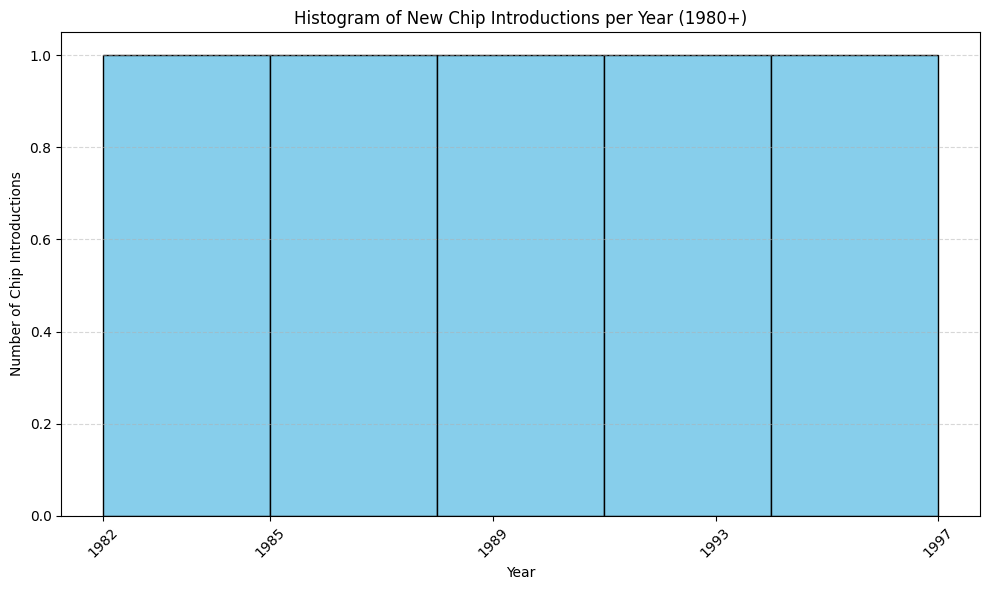

In [192]:

unique_years = np.unique(filtered_years)

plt.figure(figsize=(10,6))
plt.hist(filtered_years, bins=len(unique_years), edgecolor='black', color='skyblue')
plt.xlabel('Year')
plt.ylabel('Number of Chip Introductions')
plt.title('Histogram of New Chip Introductions per Year (1980+)')
plt.xticks(unique_years, rotation=45)  # show each year on x-axis
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---

## ADVANCED moves:
- The default font size and colors in Matplotlib are not great for presentations. Can you find a way to make your plots look nicer by increasing font sizes and choosing good colors? This can be as simple as updating some of the keywords in your plotting code, or you can explore Matplotlib's styling options to find a pre-made style you like. The [Matplotlib documentation on customizing plots](https://matplotlib.org/stable/tutorials/introductory/customizing.html) is a good place to start.
- What if you want to show your plot of Moore's law and the histogram of chip introductions side by side? Can you use Matplotlib's `plt.subplot()` to create a figure with two subplots, and put one plot in each?
  

Harder (may require more cleaning of the data in the CSV file):
- Color your scatter plot points based on the designer  or transistor density of the chip.
- Change the size of points based on the area of the chip. (You may need to strip the units and convert to a consistent unit before plotting.)